In [1]:
import pandas as pd
import numpy as np
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
my_df = pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv', sep='\t')

new_df = my_df.head(50)

items_price = np.array(new_df['item_price'].str.replace('$', ''))
items_price

new_df["price_without_$"] = items_price

grouped_df = new_df.groupby('item_name')
grouped_df.sum()[["quantity", "item_price", "price_without_$"]]
arr = np.array(grouped_df.sum()["price_without_$"])
multid_arr = []
for indexI, value in enumerate(arr):
    # print(indexI, value)
    new_arr = value.strip().split(" ")
    for indexX, data in enumerate(new_arr):
        new_arr[indexX] = float(data)
    
    multid_arr.append(new_arr)

# multid_arr

sums = [ sum(x) for x in multid_arr]
# sums

md_grp_df = grouped_df.count()[["quantity", "item_price", "price_without_$", "choice_description"]]
md_grp_df["total_amount_per_item"] = sums
md_grp_df

,quantity,item_price,price_without_$,choice_description,total_amount_per_item
item_name,,,,,
Barbacoa Bowl,1,1,1,1,11.75
Barbacoa Burrito,1,1,1,1,8.99
Bottled Water,1,1,1,0,1.09
Canned Soda,2,2,2,2,3.27
Carnitas Bowl,1,1,1,1,8.99
Carnitas Burrito,1,1,1,1,8.99
Chicken Bowl,6,6,6,6,67.70
Chicken Burrito,5,5,5,5,47.43
Chicken Crispy Tacos,1,1,1,1,8.75


<Axes: >

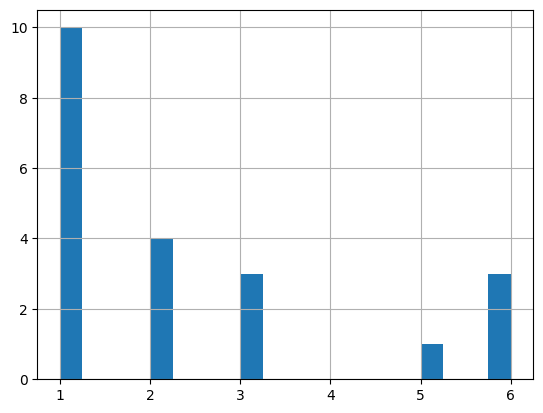

In [5]:
md_grp_df["price_without_$"].hist(bins=20)

<Axes: ylabel='Frequency'>

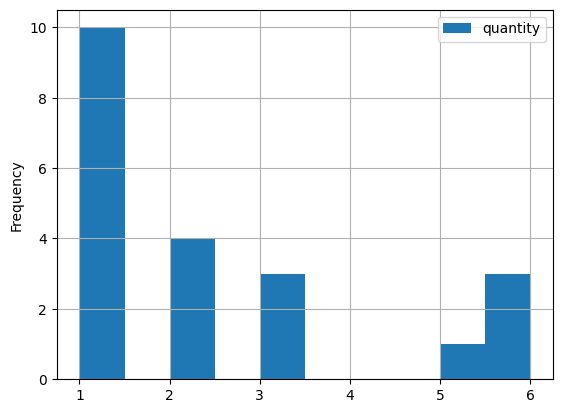

In [18]:
md_grp_df["quantity"].plot(kind="hist", legend="Quantity", grid=True)

<Axes: ylabel='Frequency'>

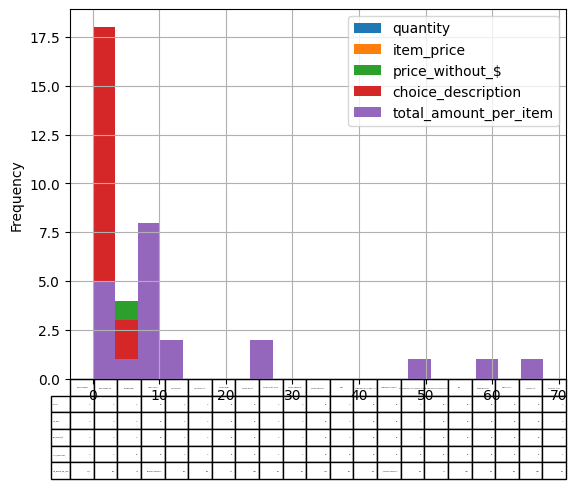

In [19]:
md_grp_df.plot(kind="hist", legend=True, bins=20, table=True, grid=True)

<Axes: title={'center': 'Food Charts'}, xlabel='item_name'>

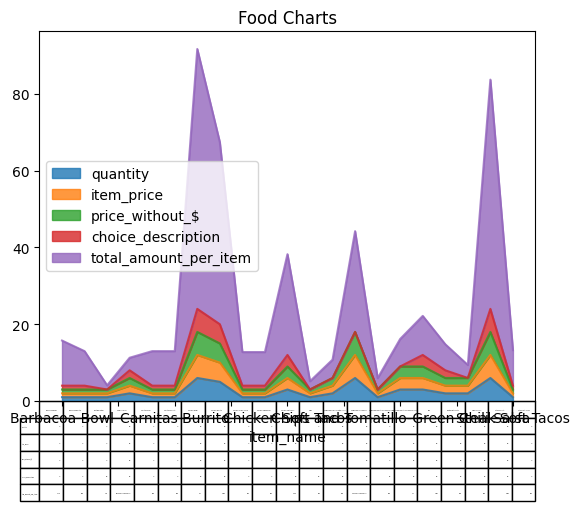

In [17]:
md_grp_df.plot(kind="area", legend=True, table=True, alpha=0.8, title="Food Charts")

<Axes: xlabel='item_name'>

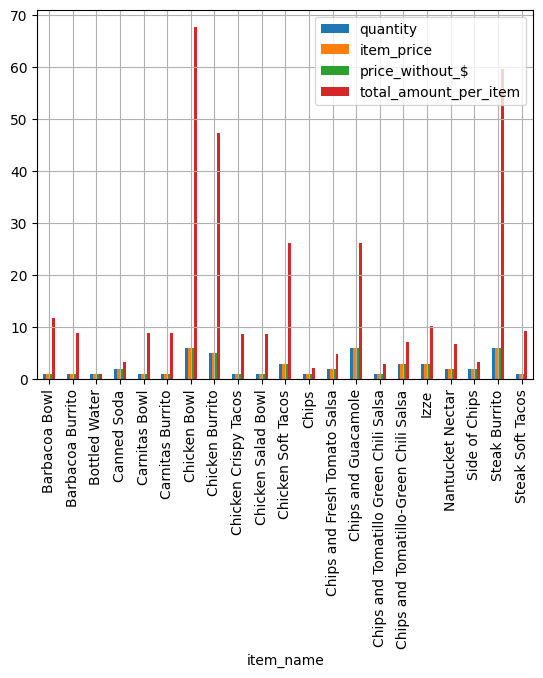

In [21]:
md_grp_df[["quantity", "item_price", "price_without_$", "total_amount_per_item"]].plot(kind="bar", legend=True, grid=True)

<Axes: xlabel='item_name'>

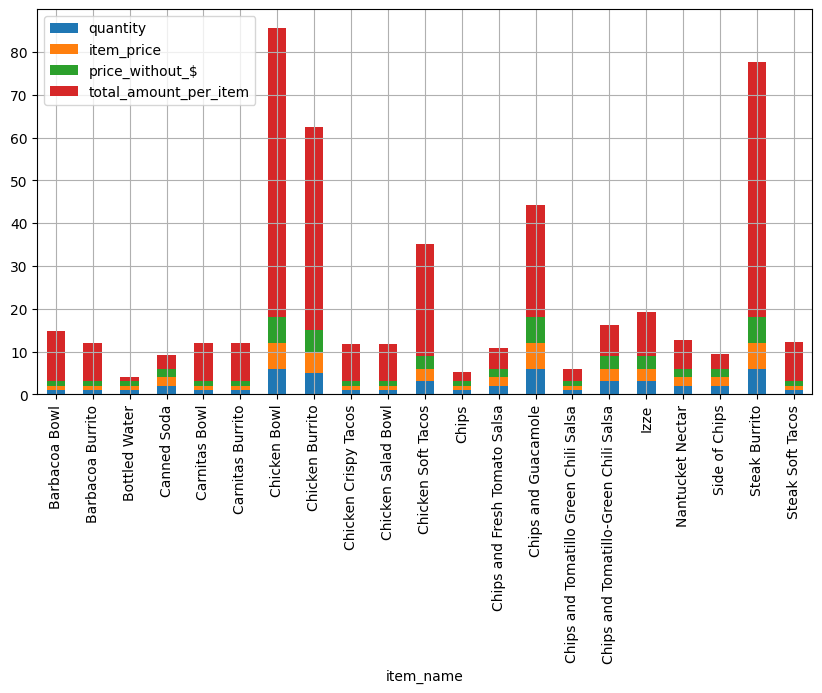

In [23]:
md_grp_df[["quantity", "item_price", "price_without_$", "total_amount_per_item"]].plot(kind="bar", legend=True, grid=True, stacked=True, figsize=(10,5))

<Axes: xlabel='item_name'>

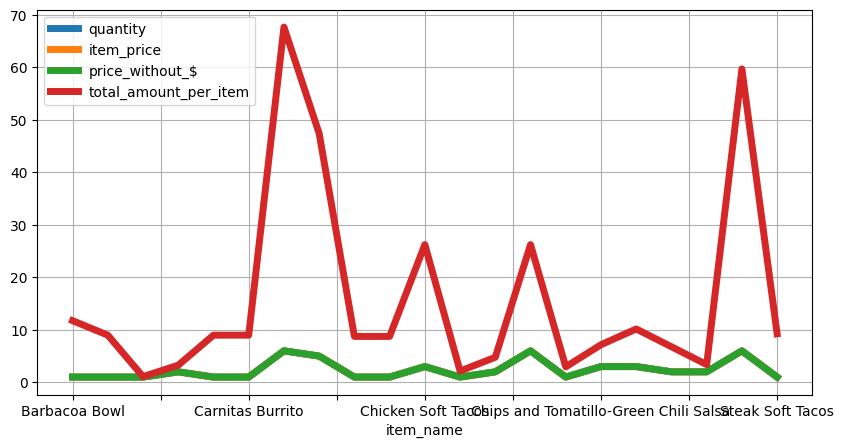

In [25]:
md_grp_df[["quantity", "item_price", "price_without_$", "total_amount_per_item"]].plot(kind="line", legend=True, grid=True, figsize=(10,5), lw=5)

<Axes: xlabel='quantity', ylabel='total_amount_per_item'>

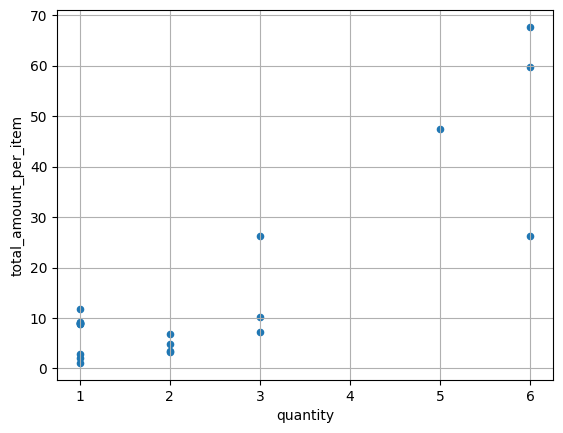

In [30]:
md_grp_df.plot(kind="scatter", x="quantity", y="total_amount_per_item", grid=True)

In [28]:
md_grp_df

,quantity,item_price,price_without_$,choice_description,total_amount_per_item
item_name,,,,,
Barbacoa Bowl,1,1,1,1,11.75
Barbacoa Burrito,1,1,1,1,8.99
Bottled Water,1,1,1,0,1.09
Canned Soda,2,2,2,2,3.27
Carnitas Bowl,1,1,1,1,8.99
Carnitas Burrito,1,1,1,1,8.99
Chicken Bowl,6,6,6,6,67.70
Chicken Burrito,5,5,5,5,47.43
Chicken Crispy Tacos,1,1,1,1,8.75


c:\Users\Hp\Documents\ML-learning\Learning Pandas\venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


<Axes: xlabel='quantity', ylabel='total_amount_per_item'>

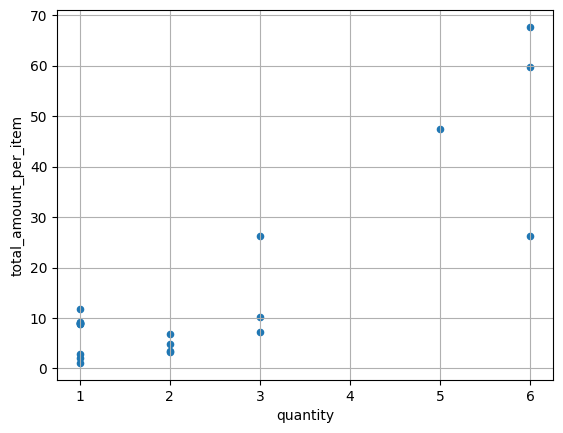

In [33]:
md_grp_df.plot(kind="scatter", x="quantity", y="total_amount_per_item", grid=True, cmap="magma")

c:\Users\Hp\Documents\ML-learning\Learning Pandas\venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


<Axes: xlabel='age', ylabel='weight'>

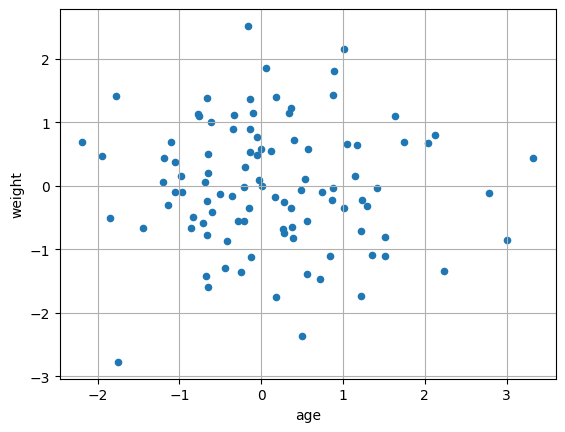

In [39]:
cancer_patient = pd.DataFrame(np.random.randn(100, 4), columns=["age", "weight", "height", "blood_pressure"])
cancer_patient
cancer_patient.plot(kind="scatter", x="age", y="weight", grid=True, cmap="magma")


<Axes: xlabel='age', ylabel='weight'>

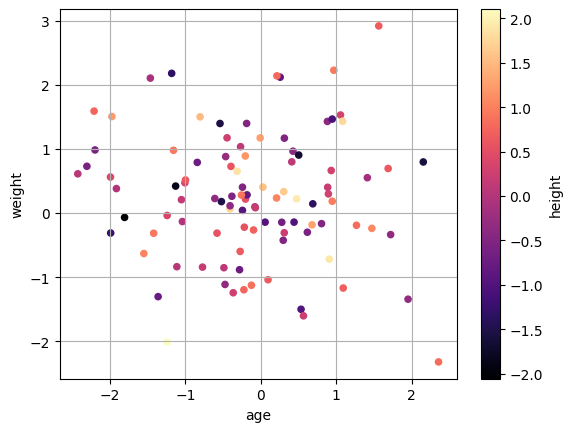

In [36]:
cancer_patient.plot(kind="scatter", x="age", y="weight", grid=True, cmap="magma", c="height")

<Axes: xlabel='age', ylabel='weight'>

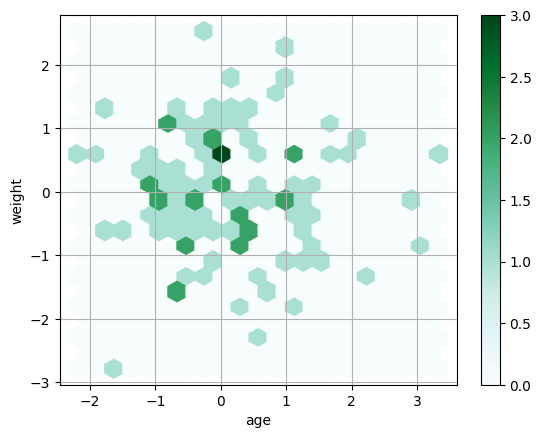

In [42]:
cancer_patient.plot(kind="hexbin", x="age", y="weight", grid=True, gridsize=20)

<Axes: ylabel='Density'>

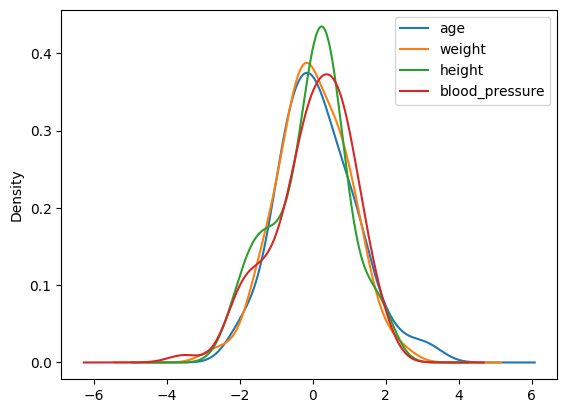

In [43]:
cancer_patient.plot(kind="kde")

<Axes: ylabel='Density'>

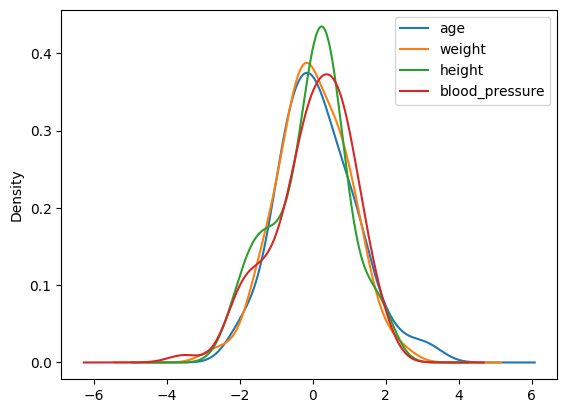

In [44]:
cancer_patient.plot(kind="density")